In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, roc_auc_score,
)
from sklearn.model_selection import (
    cross_val_score, GroupKFold, GroupShuffleSplit
)

from utils.calculador_angulos import calculate_angle, extract_angles_from_landmarks

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Bibliotecas importadas com sucesso")

✓ Bibliotecas importadas com sucesso


## 1. Import Required Libraries

# Random Forest com Features de Velocidade Angular
## Classificação de Exercícios com Diferenças de Ângulos Frame a Frame (Window=15, Stride=1)

Este notebook implementa um Random Forest usando **features de velocidade angular** em vez dos ângulos brutos.
Para cada janela de 15 frames, calcula-se a **diferença entre frames consecutivos** (Δangle = angle[t+1] − angle[t]),
capturando a *dinâmica do movimento* em vez da posição estática.

### Diferença em relação ao notebook 2 (ângulos brutos):
- **Features**: `delta_N_angle` em vez de `frame_N_angle`
- **Dimensionalidade**: janela de 15 frames → **14 deltas × 8 ângulos = 112 features** (vs 120 do modelo original)
- **Intuição**: ao invés de *"qual é o ângulo do cotovelo?"*, perguntamos *"o ângulo está aumentando ou diminuindo, e quão rápido?"*

### Garantias anti-vazamento (idênticas ao notebook 2):
- **`video_source` propagado**: cada frame carrega a origem do CSV
- **Windowing por grupo**: janelas criadas dentro de cada `(video_source, exercise)` — nunca cruzam fronteiras de vídeo
- **Stride=1**: sobreposição total, maximizando amostras de treino
- **GroupShuffleSplit / split manual**: vídeos inteiros vão para treino **ou** para teste
- **GroupKFold + Pipeline**: `StandardScaler` reajustado a cada fold sem ver os dados de validação

## 2. Load and Explore Data

In [81]:
# Configurações
OUTPUT_DIR = Path("files_brutos")
ML_MODELS_DIR = Path("ml_models")
ML_MODELS_DIR.mkdir(exist_ok=True)

# ── Divisão manual por sujeito ───────────────────────────────────────────────
# TREINO: rafael + paulo + leticia
# TESTE:  rodrigo (sujeito nunca visto no treino)

TRAIN_FILES = [
    "rafael_rosca_biceps_video_compilado_15_05_202_full_5fps_rosca_biceps.csv",
    "rafael_flexao_video_compilado_15_05_2025_full_5fps_flexao.csv",
    "rafael_descanso_video_compilado_15_05_2025_full_5fps_descanso.csv",
    "rafael_agachamento_video_compilado_15_05_2025_full_5fps_agachamento.csv",

    "paulo_2_min_rosca_direta_full_5fps_rosca_biceps_paulo.csv",
    "paulo_2_min_flexao_full_5fps_flexao_paulo.csv",
    "paulo_2_min_agachamento_full_5fps_agachamento_paulo.csv",

    "leticia_flexao720p_full_5fps_flexao.csv",
    "leticia_Descanso720p (3)_full_5fps_descanso.csv",
    "leticia_biceps720p_full_5fps_rosca_biceps.csv",
    "leticia_agachamento720p_full_5fps_agachamento.csv",
]

TEST_FILES = [
    "1 - rodrigo_descanso_consolidado_full_5fps_descanso.csv",
    "1 - flexao_full_5fps_flexao.csv",
    "1 - rodrigo_agachamento2.csv",
    "1 - rodrigo_roscadireta2.csv",
]


def load_files(file_list, split_tag):
    dfs = []
    for csv_file in file_list:
        csv_path = OUTPUT_DIR / csv_file
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df['video_source'] = csv_file
            df['split'] = split_tag
            print(f"  ✓ {csv_file}  →  {df['exercise'].unique()[0]}")
            dfs.append(df)
        else:
            print(f"  ✗ NÃO ENCONTRADO: {csv_file}")
    return pd.concat(dfs, axis=0, ignore_index=True)


print("📂 Carregando arquivos de TREINO (rafael + paulo + leticia):")
data_raw_train = load_files(TRAIN_FILES, 'train')

print(f"\n📂 Carregando arquivos de TESTE (rodrigo):")
data_raw_test = load_files(TEST_FILES, 'test')

data_raw = pd.concat([data_raw_train, data_raw_test], axis=0, ignore_index=True)
print(f"\n📊 Total: {data_raw.shape[0]} linhas  |  {data_raw['video_source'].nunique()} vídeos")
print(f"   Treino: {len(data_raw_train):>6} linhas  ({data_raw_train['video_source'].nunique()} vídeos)")
print(f"   Teste:  {len(data_raw_test):>6} linhas  ({data_raw_test['video_source'].nunique()} vídeos)")


📂 Carregando arquivos de TREINO (rafael + paulo + leticia):
  ✓ rafael_rosca_biceps_video_compilado_15_05_202_full_5fps_rosca_biceps.csv  →  rosca_biceps
  ✓ rafael_flexao_video_compilado_15_05_2025_full_5fps_flexao.csv  →  flexao
  ✓ rafael_descanso_video_compilado_15_05_2025_full_5fps_descanso.csv  →  descanso
  ✓ rafael_agachamento_video_compilado_15_05_2025_full_5fps_agachamento.csv  →  agachamento
  ✓ paulo_2_min_rosca_direta_full_5fps_rosca_biceps_paulo.csv  →  rosca_biceps
  ✓ paulo_2_min_flexao_full_5fps_flexao_paulo.csv  →  flexao
  ✓ paulo_2_min_agachamento_full_5fps_agachamento_paulo.csv  →  agachamento
  ✓ leticia_flexao720p_full_5fps_flexao.csv  →  flexao
  ✓ leticia_Descanso720p (3)_full_5fps_descanso.csv  →  descanso
  ✓ leticia_biceps720p_full_5fps_rosca_biceps.csv  →  rosca_biceps
  ✓ leticia_agachamento720p_full_5fps_agachamento.csv  →  agachamento

📂 Carregando arquivos de TESTE (rodrigo):
  ✓ 1 - rodrigo_descanso_consolidado_full_5fps_descanso.csv  →  descanso
  ✓ 1

In [82]:
# Extrair ângulos — video_source é propagado automaticamente pela função
print("Extraindo ângulos dos landmarks...")
data = extract_angles_from_landmarks(data_raw)

# Reatachar coluna 'split' via video_source (cada vídeo tem um único split)
split_map = data_raw.drop_duplicates('video_source').set_index('video_source')['split']
data['split'] = data['video_source'].map(split_map)

print(f"✓ Ângulos extraídos: {data.shape[0]} frames, {data.shape[1]} colunas")
print(f"\n📊 Distribuição por exercício:")
print(data['exercise'].value_counts())
print(f"\n📹 Frames por vídeo (split):")
for vs, grp in data.groupby('video_source'):
    print(f"  [{grp['split'].iloc[0]:5}] {vs}: {len(grp)} frames")

Extraindo ângulos dos landmarks...
✓ Ângulos extraídos: 14435 frames, 21 colunas

📊 Distribuição por exercício:
exercise
descanso        4300
rosca_biceps    3751
agachamento     3582
flexao          2802
Name: count, dtype: int64

📹 Frames por vídeo (split):
  [test ] 1 - flexao_full_5fps_flexao.csv: 511 frames
  [test ] 1 - rodrigo_agachamento2.csv: 712 frames
  [test ] 1 - rodrigo_descanso_consolidado_full_5fps_descanso.csv: 1694 frames
  [test ] 1 - rodrigo_roscadireta2.csv: 671 frames
  [train] leticia_Descanso720p (3)_full_5fps_descanso.csv: 866 frames
  [train] leticia_agachamento720p_full_5fps_agachamento.csv: 784 frames
  [train] leticia_biceps720p_full_5fps_rosca_biceps.csv: 630 frames
  [train] leticia_flexao720p_full_5fps_flexao.csv: 589 frames
  [train] paulo_2_min_agachamento_full_5fps_agachamento_paulo.csv: 499 frames
  [train] paulo_2_min_flexao_full_5fps_flexao_paulo.csv: 509 frames
  [train] paulo_2_min_rosca_direta_full_5fps_rosca_biceps_paulo.csv: 691 frames
  [trai

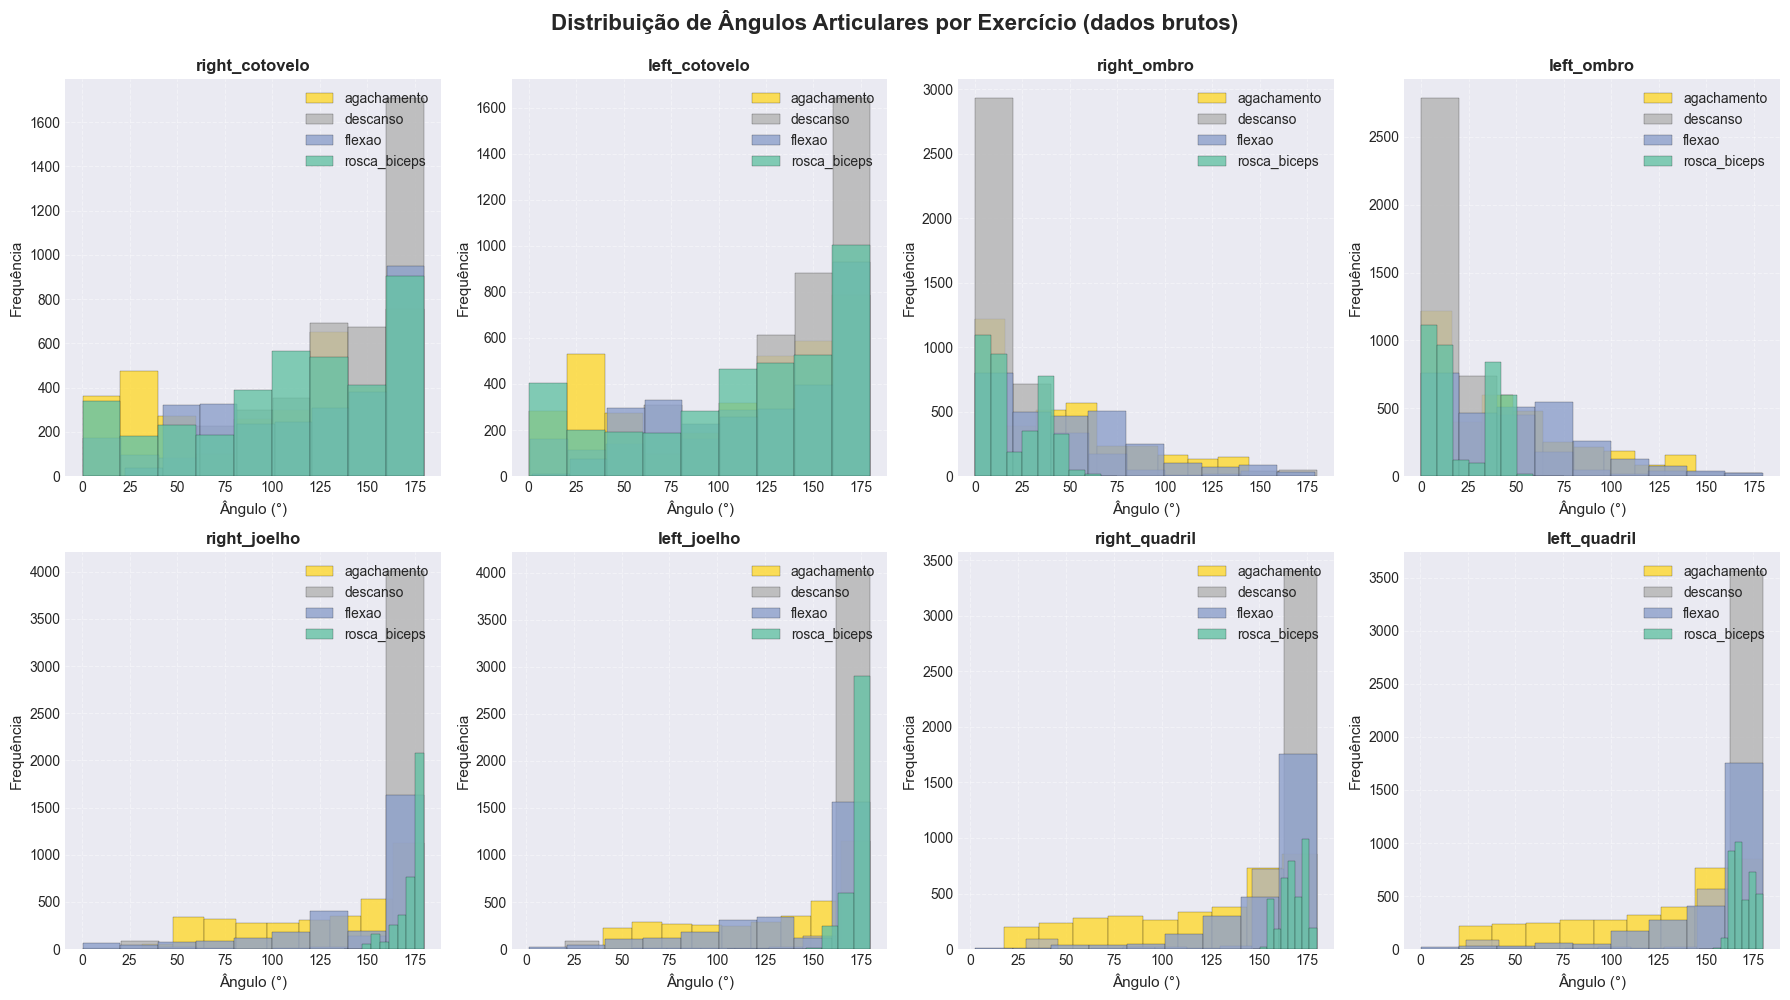

In [69]:
# Visualizar distribuições com melhor contraste
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

colors = plt.cm.Set2(np.linspace(0, 1, len(data['exercise'].unique())))
exercise_colors = {ex: colors[i] for i, ex in enumerate(data['exercise'].unique())}

angle_columns = ['right_cotovelo', 'left_cotovelo', 'right_ombro', 'left_ombro',
                 'right_joelho', 'left_joelho', 'right_quadril', 'left_quadril']

for idx, col in enumerate(angle_columns):
    for exercise in sorted(data['exercise'].unique()):
        subset = data[data['exercise'] == exercise][col]
        axes[idx].hist(subset, alpha=0.8, label=exercise, bins=9,
                       color=exercise_colors[exercise], edgecolor='black', linewidth=0.2)
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Ângulo (°)', fontsize=11)
    axes[idx].set_ylabel('Frequência', fontsize=11)
    axes[idx].legend(fontsize=10, loc='upper right', framealpha=0.95)
    axes[idx].grid(alpha=0.4, linestyle='--')

plt.suptitle('Distribuição de Ângulos Articulares por Exercício (dados brutos)',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 3. Velocity Feature Engineering

### Diferença em relação ao notebook 2:
Em vez de usar os **ângulos absolutos** de cada frame na janela, calculamos a **diferença entre frames consecutivos**.

```
Notebook 2 (ângulos brutos):     frame_1_cotovelo, frame_2_cotovelo, ..., frame_15_cotovelo  →  15 × 8 = 120 features
Notebook 3 (velocidade angular): delta_1_cotovelo, delta_2_cotovelo, ..., delta_14_cotovelo  →  14 × 8 = 112 features
  onde delta_i = angle[frame_{i+1}] − angle[frame_i]
```

- **Valor positivo (Δ > 0)**: articulação abrindo (ângulo aumentando)
- **Valor negativo (Δ < 0)**: articulação fechando (ângulo diminuindo)
- **Valor zero (Δ ≈ 0)**: articulação parada

### Hipótese:
A velocidade angular pode ser mais discriminativa que a posição absoluta para exercícios onde o *padrão de movimento* importa mais que a *postura* em si.

In [83]:
def create_velocity_features_window(df, window_size=15, stride=1, angle_columns=None):
    """
    Cria features de VELOCIDADE ANGULAR usando janelas deslizantes.

    Para cada janela de N frames, calcula (N-1) diferenças consecutivas por ângulo:
        delta_i = angle[frame_{i+1}] - angle[frame_i]

    window_size=15 → 14 deltas × 8 ângulos = 112 features

    Agrupamento por (video_source, exercise) garante que nenhuma janela
    cruza fronteiras de vídeo — mesmo protocolo anti-vazamento do notebook 2.
    """
    if angle_columns is None:
        angle_columns = [
            'right_cotovelo', 'right_ombro', 'left_cotovelo', 'left_ombro',
            'right_joelho', 'right_quadril', 'left_joelho', 'left_quadril'
        ]

    features_list = []
    labels_list = []
    meta_list = []

    for (video_source, exercise), group in df.groupby(['video_source', 'exercise'], sort=False):
        group = group.sort_values('frame').reset_index(drop=True)
        n = len(group)
        split_tag = group['split'].iloc[0]

        for i in range(0, n - window_size + 1, stride):
            window = group.iloc[i:i + window_size]
            window_features = {}
            # Calcular (window_size - 1) diferenças consecutivas por ângulo
            for delta_idx in range(window_size - 1):
                frame_curr = window.iloc[delta_idx]
                frame_next = window.iloc[delta_idx + 1]
                for angle_col in angle_columns:
                    delta = frame_next[angle_col] - frame_curr[angle_col]
                    window_features[f'delta_{delta_idx + 1}_{angle_col}'] = delta

            features_list.append(window_features)
            labels_list.append(exercise)
            meta_list.append({'video_source': video_source, 'split': split_tag})

    X = pd.DataFrame(features_list)
    y = pd.Series(labels_list, name='exercise')
    meta = pd.DataFrame(meta_list)

    n_deltas = window_size - 1
    print(f"✓ Features de velocidade criadas: {X.shape[0]} amostras, {X.shape[1]} features")
    print(f"  Janela: {window_size} frames → {n_deltas} deltas × {len(angle_columns)} ângulos = {n_deltas * len(angle_columns)} features")
    print(f"  Stride: {stride}  ({'sobreposição total' if stride == 1 else f'janelas compartilham {window_size - stride}/{window_size} frames'})")
    print(f"  Grupos: {df.groupby(['video_source', 'exercise']).ngroups} combinações (vídeo × exercício)")
    for tag in ['train', 'test']:
        cnt = (meta['split'] == tag).sum()
        print(f"  {tag.upper():5}: {cnt} janelas")

    return X, y, meta


angle_columns = ['right_cotovelo', 'left_cotovelo', 'right_ombro', 'left_ombro',
                 'right_joelho', 'left_joelho', 'right_quadril', 'left_quadril']

print("Criando features de velocidade (window=15, stride=1) para todos os vídeos...")
X, y, meta = create_velocity_features_window(data, window_size=15, stride=1, angle_columns=angle_columns)
print(f"\nShape de X:    {X.shape}")
print(f"Shape de y:    {y.shape}")
print(f"Shape de meta: {meta.shape}")

Criando features de velocidade (window=15, stride=1) para todos os vídeos...
✓ Features de velocidade criadas: 14225 amostras, 112 features
  Janela: 15 frames → 14 deltas × 8 ângulos = 112 features
  Stride: 1  (sobreposição total)
  Grupos: 15 combinações (vídeo × exercício)
  TRAIN: 10693 janelas
  TEST : 3532 janelas

Shape de X:    (14225, 112)
Shape de y:    (14225,)
Shape de meta: (14225, 2)


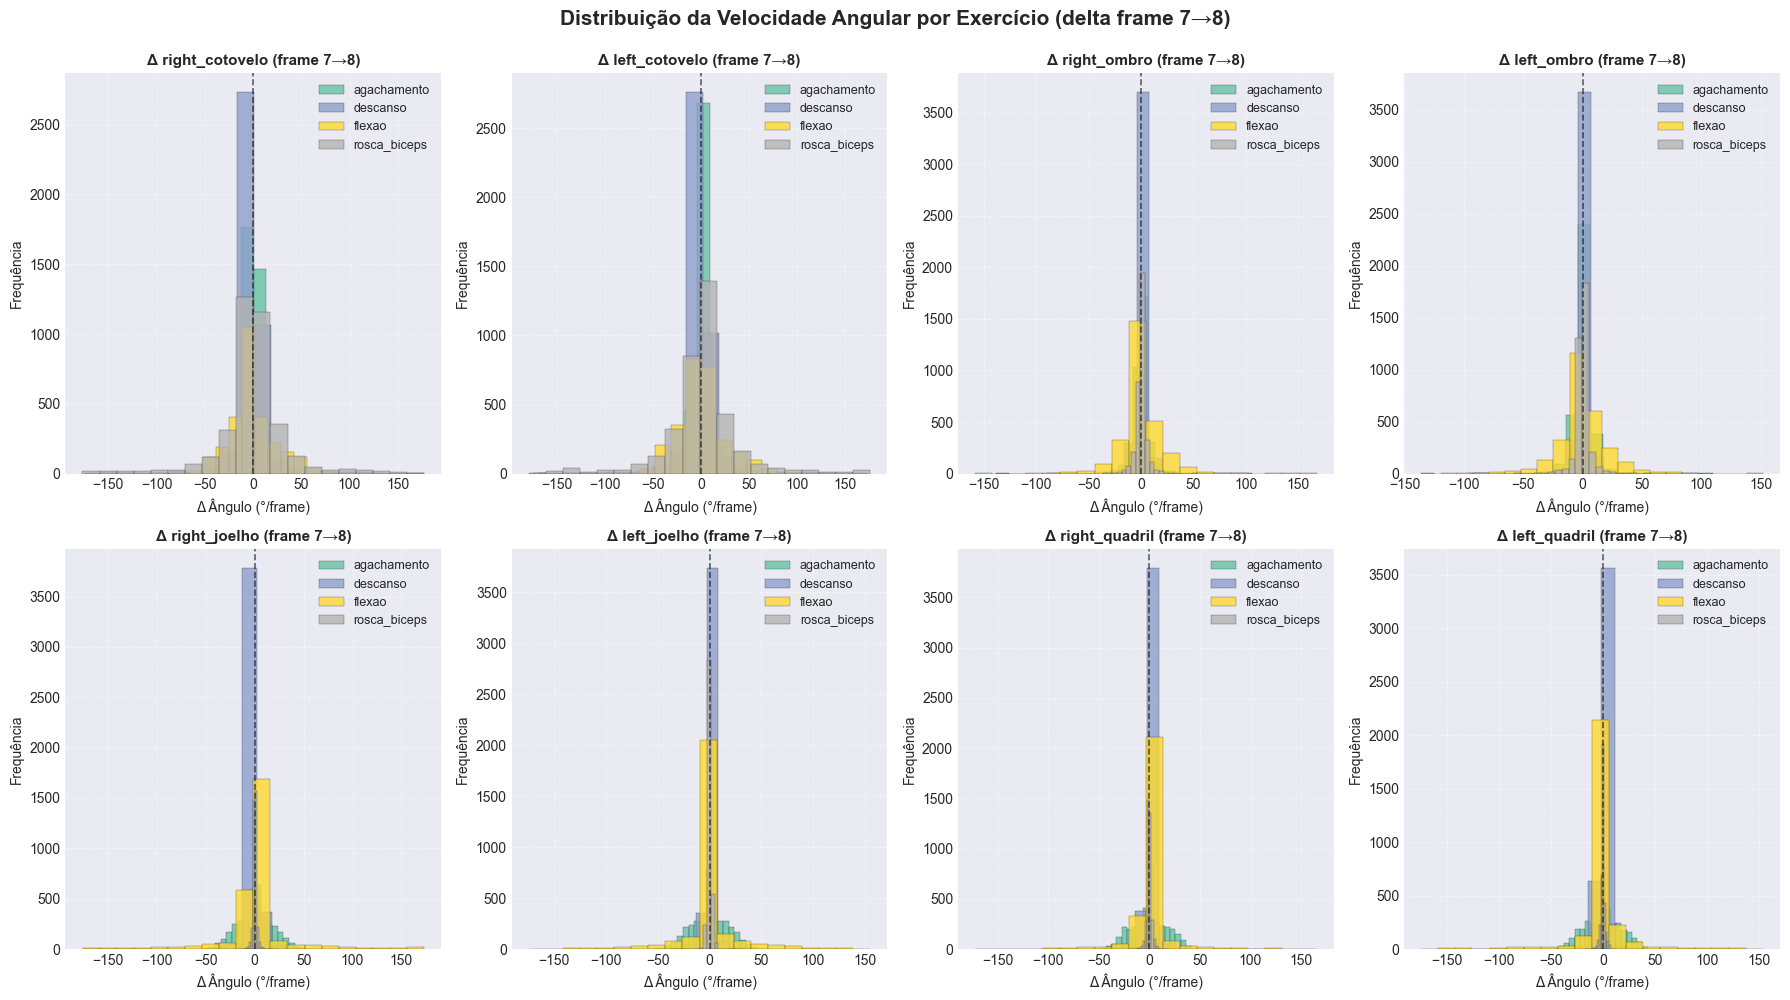

In [71]:
# Visualizar distribuições das features de velocidade
# Esperamos que os deltas durante descanso sejam próximos de zero
# e durante exercícios tenham maior variação
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

# Usar o delta central (posição 7 de 14) como representativo da janela
delta_cols = [f'delta_7_{col}' for col in angle_columns]

colors = plt.cm.Set2(np.linspace(0, 1, len(y.unique())))
exercise_colors = {ex: colors[i] for i, ex in enumerate(sorted(y.unique()))}

for idx, (delta_col, angle_col) in enumerate(zip(delta_cols, angle_columns)):
    for exercise in sorted(y.unique()):
        subset = X.loc[y == exercise, delta_col]
        axes[idx].hist(subset, alpha=0.8, label=exercise, bins=20,
                       color=exercise_colors[exercise], edgecolor='black', linewidth=0.2)
    axes[idx].axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
    axes[idx].set_title(f'Δ {angle_col} (frame 7→8)', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Δ Ângulo (°/frame)', fontsize=10)
    axes[idx].set_ylabel('Frequência', fontsize=10)
    axes[idx].legend(fontsize=9, loc='upper right', framealpha=0.95)
    axes[idx].grid(alpha=0.4, linestyle='--')

plt.suptitle('Distribuição da Velocidade Angular por Exercício (delta frame 7→8)',
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [72]:
y.value_counts()

exercise
descanso        4258
rosca_biceps    3695
agachamento     3526
flexao          2746
Name: count, dtype: int64

## 4. Preprocess and Prepare Features

In [84]:
# Codificar labels — 4 classes
label_map = {
    'flexao':       0,
    'agachamento':  1,
    'descanso':     2,
    'rosca_biceps': 3,
}
reverse_label_map = {v: k for k, v in label_map.items()}

y_encoded = y.map(label_map)
groups = meta['video_source']

# ── Split manual por sujeito ─────────────────────────────────────────────────
# Treino = rafael + paulo + leticia  |  Teste = rodrigo
train_mask = meta['split'] == 'train'
test_mask  = meta['split'] == 'test'

X_train = X[train_mask].reset_index(drop=True)
X_test  = X[test_mask].reset_index(drop=True)
y_train = y_encoded[train_mask].reset_index(drop=True)
y_test  = y_encoded[test_mask].reset_index(drop=True)
groups_train = groups[train_mask].reset_index(drop=True)
groups_test  = groups[test_mask].reset_index(drop=True)

print("✓ Labels codificados (4 classes):")
for exercise, label in label_map.items():
    n_tr = (y_train == label).sum()
    n_te = (y_test  == label).sum()
    print(f"  {exercise:15} ({label}): treino={n_tr:5d}  teste={n_te:5d}")

print(f"\n✓ Split por sujeito (sem vazamento):")
print(f"  Treino (rafael + paulo + leticia): {len(X_train):5d} janelas  — {sorted(groups_train.unique().tolist())}")
print(f"  Teste  (rodrigo):                  {len(X_test):5d} janelas  — {sorted(groups_test.unique().tolist())}")

print(f"\n  Distribuição treino por classe:")
for label, exercise in sorted([(v, k) for k, v in label_map.items()]):
    count = (y_train == label).sum()
    if count > 0:
        print(f"    {exercise:15}: {count:5d} ({count/len(y_train)*100:5.1f}%)")

print(f"\n  Distribuição teste por classe:")
for label, exercise in sorted([(v, k) for k, v in label_map.items()]):
    count = (y_test == label).sum()
    if count > 0:
        print(f"    {exercise:15}: {count:5d} ({count/len(y_test)*100:5.1f}%)")

✓ Labels codificados (4 classes):
  flexao          (0): treino= 2249  teste=  497
  agachamento     (1): treino= 2828  teste=  698
  descanso        (2): treino= 2578  teste= 1680
  rosca_biceps    (3): treino= 3038  teste=  657

✓ Split por sujeito (sem vazamento):
  Treino (rafael + paulo + leticia): 10693 janelas  — ['leticia_Descanso720p (3)_full_5fps_descanso.csv', 'leticia_agachamento720p_full_5fps_agachamento.csv', 'leticia_biceps720p_full_5fps_rosca_biceps.csv', 'leticia_flexao720p_full_5fps_flexao.csv', 'paulo_2_min_agachamento_full_5fps_agachamento_paulo.csv', 'paulo_2_min_flexao_full_5fps_flexao_paulo.csv', 'paulo_2_min_rosca_direta_full_5fps_rosca_biceps_paulo.csv', 'rafael_agachamento_video_compilado_15_05_2025_full_5fps_agachamento.csv', 'rafael_descanso_video_compilado_15_05_2025_full_5fps_descanso.csv', 'rafael_flexao_video_compilado_15_05_2025_full_5fps_flexao.csv', 'rafael_rosca_biceps_video_compilado_15_05_202_full_5fps_rosca_biceps.csv']
  Teste  (rodrigo):        

In [85]:
# ── Balanceamento por undersampling (dentro de treino e teste separadamente) ─
# Garante igual número de janelas por classe em cada split, sem cruzar fronteiras

rng = np.random.RandomState(42)

def undersample_balanced(X_split, y_split, groups_split, label_map, rng):
    """Undersample cada classe para o mínimo encontrado no split."""
    min_count = y_split.value_counts().min()
    parts_X, parts_y, parts_g = [], [], []
    for label in sorted(label_map.values()):
        mask = y_split == label
        if mask.sum() == 0:
            continue
        idx = np.where(mask)[0]
        chosen = rng.choice(idx, size=min_count, replace=False)
        parts_X.append(X_split.iloc[chosen])
        parts_y.append(y_split.iloc[chosen])
        parts_g.append(groups_split.iloc[chosen])
    X_bal = pd.concat(parts_X).reset_index(drop=True)
    y_bal = pd.concat(parts_y).reset_index(drop=True)
    g_bal = pd.concat(parts_g).reset_index(drop=True)
    return X_bal, y_bal, g_bal


X_train, y_train, groups_train = undersample_balanced(X_train, y_train, groups_train, label_map, rng)
X_test,  y_test,  groups_test  = undersample_balanced(X_test,  y_test,  groups_test,  label_map, rng)

print("✓ Classes balanceadas por undersampling (min por classe em cada split):")
print(f"\n  Treino ({len(X_train)} janelas):")
for label, exercise in sorted([(v, k) for k, v in label_map.items()]):
    n = (y_train == label).sum()
    if n > 0:
        print(f"    {exercise:15}: {n:5d}")

print(f"\n  Teste ({len(X_test)} janelas):")
for label, exercise in sorted([(v, k) for k, v in label_map.items()]):
    n = (y_test == label).sum()
    if n > 0:
        print(f"    {exercise:15}: {n:5d}")

✓ Classes balanceadas por undersampling (min por classe em cada split):

  Treino (8996 janelas):
    flexao         :  2249
    agachamento    :  2249
    descanso       :  2249
    rosca_biceps   :  2249

  Teste (1988 janelas):
    flexao         :   497
    agachamento    :   497
    descanso       :   497
    rosca_biceps   :   497


In [86]:
# Pipeline: scaler + modelo em sequência
# O scaler é reajustado a cada fold do CV — sem vazamento de estatísticas.
# Hiperparâmetros idênticos ao notebook 2 para comparação justa.
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_split=3,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced',
    ))
])

print("✓ Pipeline criado: StandardScaler → RandomForestClassifier")
print(f"  Steps: {[name for name, _ in pipe.steps]}")
print(f"  Features de entrada: {X_train.shape[1]} (14 deltas × 8 ângulos)")

✓ Pipeline criado: StandardScaler → RandomForestClassifier
  Steps: ['scaler', 'rf']
  Features de entrada: 112 (14 deltas × 8 ângulos)


In [ ]:
## 4b. Cross-Validation Leave-One-Subject-Out (LOSO)

**4 folds** — cada sujeito é deixado de fora uma vez como validação.  
Treinado em todos os dados disponíveis (todos os 4 sujeitos), sem o split fixo.


In [92]:
from sklearn.model_selection import LeaveOneGroupOut

# ── Mapear vídeo → sujeito ──────────────────────────────────────────────────
def get_subject(row):
    src = row['video_source'].lower()
    if 'rafael' in src:
        return 'rafael'
    elif 'paulo' in src:
        return 'paulo'
    elif 'leticia' in src:
        return 'leticia'
    elif 'rodrigo' in src:
        return 'rodrigo'
    elif row['split'] == 'test':
        return 'rodrigo'   # "1 - flexao_full_5fps_flexao.csv" não tem "rodrigo" no nome
    return 'unknown'

subjects = meta.apply(get_subject, axis=1)
print("Sujeitos encontrados:", subjects.value_counts().to_dict())

# ── LOSO Cross-Validation ───────────────────────────────────────────────────
logo = LeaveOneGroupOut()

cv_results = []
for fold, (train_idx, val_idx) in enumerate(logo.split(X, y_encoded, groups=subjects)):
    subject_out = subjects.iloc[val_idx[0]]

    X_cv_train = X.iloc[train_idx]
    y_cv_train = y_encoded.iloc[train_idx]
    X_cv_val   = X.iloc[val_idx]
    y_cv_val   = y_encoded.iloc[val_idx]

    # Balancear treino por undersampling
    rng_cv = np.random.RandomState(42)
    min_tr = y_cv_train.value_counts().min()
    parts_X, parts_y = [], []
    for lbl in sorted(label_map.values()):
        mask = y_cv_train == lbl
        if mask.sum() == 0:
            continue
        idx_lbl = np.where(mask)[0]
        chosen = rng_cv.choice(idx_lbl, size=min_tr, replace=False)
        parts_X.append(X_cv_train.iloc[chosen])
        parts_y.append(y_cv_train.iloc[chosen])
    X_cv_train_bal = pd.concat(parts_X).reset_index(drop=True)
    y_cv_train_bal = pd.concat(parts_y).reset_index(drop=True)

    # Balancear validação
    min_val = y_cv_val.value_counts().min()
    parts_Xv, parts_yv = [], []
    for lbl in sorted(label_map.values()):
        mask = y_cv_val == lbl
        if mask.sum() == 0:
            continue
        idx_lbl = np.where(mask)[0]
        chosen = rng_cv.choice(idx_lbl, size=min_val, replace=False)
        parts_Xv.append(X_cv_val.iloc[chosen])
        parts_yv.append(y_cv_val.iloc[chosen])
    X_cv_val_bal = pd.concat(parts_Xv).reset_index(drop=True)
    y_cv_val_bal = pd.concat(parts_yv).reset_index(drop=True)

    # Clone do pipeline para este fold
    from sklearn.base import clone
    pipe_cv = clone(pipe)
    pipe_cv.fit(X_cv_train_bal, y_cv_train_bal)

    acc = accuracy_score(y_cv_val_bal, pipe_cv.predict(X_cv_val_bal))
    f1  = f1_score(y_cv_val_bal, pipe_cv.predict(X_cv_val_bal), average='weighted')
    cv_results.append({'fold': fold + 1, 'subject': subject_out, 'accuracy': acc, 'f1': f1})
    print(f"  Fold {fold+1} ({subject_out:8}): acc={acc:.3f}  f1={f1:.3f}"
          f"  [treino={len(X_cv_train_bal)}  val={len(X_cv_val_bal)}]")

cv_results_df = pd.DataFrame(cv_results)
mean_acc = cv_results_df['accuracy'].mean()
std_acc  = cv_results_df['accuracy'].std()
mean_f1  = cv_results_df['f1'].mean()
std_f1   = cv_results_df['f1'].std()

print(f"\n{'='*55}")
print(f"  LOSO CV  —  4 folds (RF Velocidade Angular)")
print(f"{'='*55}")
print(f"  Accuracy média : {mean_acc:.3f} ± {std_acc:.3f}")
print(f"  F1 média       : {mean_f1:.3f} ± {std_f1:.3f}")
print(f"{'='*55}")


Sujeitos encontrados: {'rafael': 6223, 'rodrigo': 3532, 'leticia': 2813, 'paulo': 1657}
  Fold 1 (leticia ): acc=0.513  f1=0.496  [treino=8684  val=2300]
  Fold 2 (paulo   ): acc=0.860  f1=0.860  [treino=9004  val=1455]
  Fold 3 (rafael  ): acc=0.721  f1=0.720  [treino=6268  val=4716]
  Fold 4 (rodrigo ): acc=0.667  f1=0.626  [treino=8996  val=1988]

  LOSO CV  —  4 folds (RF Velocidade Angular)
  Accuracy média : 0.690 ± 0.144
  F1 média       : 0.676 ± 0.153


## 5. Train Random Forest Classifier

In [87]:
# Armazenar valores nulos para compatibilidade com célula de resumo
cv_scores_accuracy = np.array([np.nan])
cv_scores_f1       = np.array([np.nan])

# Treinar pipeline em todos os dados de treino
print("🔧 Treinando pipeline com features de velocidade angular...")
pipe.fit(X_train, y_train)
print("✓ Pipeline treinado!")
print(f"  Amostras de treino: {len(X_train)}  |  Features: {X_train.shape[1]}")

🔧 Treinando pipeline com features de velocidade angular...
✓ Pipeline treinado!
  Amostras de treino: 8996  |  Features: 112


## 6. Evaluate Model Performance

In [88]:
# Predições — o pipeline aplica o scaler automaticamente
y_train_pred = pipe.predict(X_train)
y_test_pred  = pipe.predict(X_test)

y_train_proba = pipe.predict_proba(X_train)
y_test_proba  = pipe.predict_proba(X_test)

# Métricas
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy  = accuracy_score(y_test,  y_test_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1  = f1_score(y_test,  y_test_pred,  average='weighted')

classes_in_test = np.unique(y_test)
classes_all     = np.array(sorted(label_map.values()))
missing_in_test = [reverse_label_map[c] for c in classes_all if c not in classes_in_test]

try:
    if len(missing_in_test) > 0:
        present_idx = [i for i, c in enumerate(classes_all) if c in classes_in_test]
        test_auc = roc_auc_score(
            y_test, y_test_proba[:, present_idx],
            multi_class='ovr', labels=classes_in_test
        )
    else:
        test_auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr')
    train_auc = roc_auc_score(y_train, y_train_proba, multi_class='ovr')
except Exception:
    train_auc = 0.0
    test_auc  = 0.0

target_names = [reverse_label_map[i] for i in sorted(label_map.values())]
cm = confusion_matrix(y_test, y_test_pred, labels=sorted(label_map.values()))

print(f"📊 Resultados no conjunto de TESTE (Rodrigo — nunca visto no treino):")
if missing_in_test:
    print(f"  ⚠️  Classes ausentes no teste: {missing_in_test}")
print(f"  Accuracy:      {test_accuracy:.4f}  (treino: {train_accuracy:.4f})")
print(f"  F1 (weighted): {test_f1:.4f}  (treino: {train_f1:.4f})")
if test_auc > 0:
    print(f"  AUC-ROC (ovr): {test_auc:.4f}  (treino: {train_auc:.4f})")

📊 Resultados no conjunto de TESTE (Rodrigo — nunca visto no treino):
  Accuracy:      0.6670  (treino: 0.7211)
  F1 (weighted): 0.6256  (treino: 0.6967)
  AUC-ROC (ovr): 0.8927  (treino: 0.9076)


## 7. Visualizando resultado das previsões

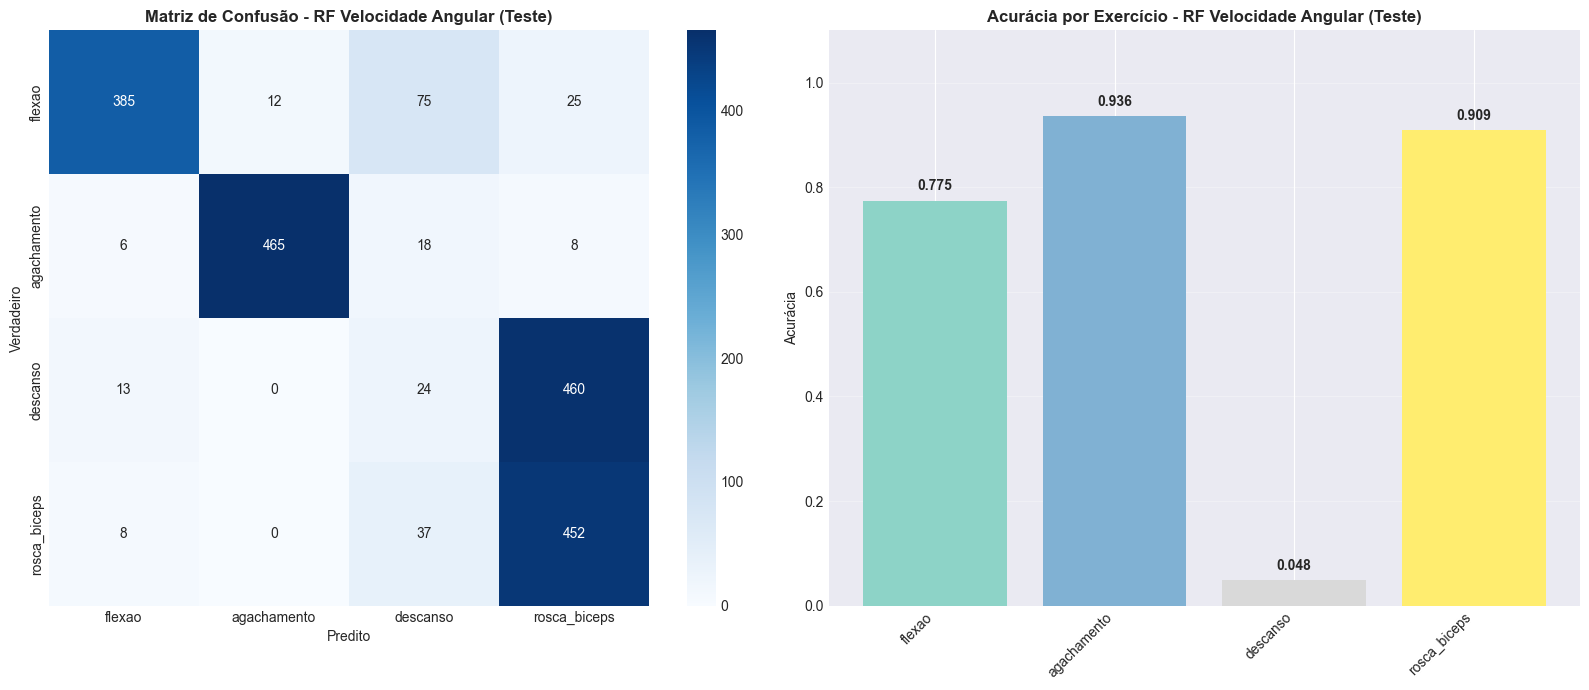

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Matriz de Confusão
exercise_names = [reverse_label_map[i] for i in sorted(label_map.values())]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=True,
            xticklabels=exercise_names, yticklabels=exercise_names)
axes[0].set_title('Matriz de Confusão - RF Velocidade Angular (Teste)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Verdadeiro')
axes[0].set_xlabel('Predito')

# 2. Acurácia por Classe
per_class_totals = cm.sum(axis=1)
with np.errstate(divide='ignore', invalid='ignore'):
    per_class_accuracy = np.where(per_class_totals > 0, cm.diagonal() / per_class_totals, np.nan)
colors_per_class = plt.cm.Set3(np.linspace(0, 1, len(exercise_names)))
axes[1].bar(
    exercise_names,
    [v if not np.isnan(v) else 0 for v in per_class_accuracy],
    color=colors_per_class
)
axes[1].set_ylabel('Acurácia')
axes[1].set_title('Acurácia por Exercício - RF Velocidade Angular (Teste)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1.1])
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(per_class_accuracy):
    label_txt = f'{v:.3f}' if not np.isnan(v) else 'n/a'
    axes[1].text(i, (v if not np.isnan(v) else 0) + 0.02, label_txt,
                 ha='center', fontweight='bold')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 7b. Acurácia Apenas em Exercícios Ativos (sem Descanso)

  ACURÁCIA — APENAS EXERCÍCIOS ATIVOS (flexão, agach., rosca)

  Conjunto      Acurácia (active)
  --------------------------------
  Treino                   0.8819
  Teste                    0.8732

  CLASSIFICATION REPORT — TREINO (active)
              precision    recall  f1-score   support

      flexao       0.91      0.87      0.89      2249
 agachamento       1.00      0.89      0.94      2249
rosca_biceps       0.84      0.89      0.86      2249

   micro avg       0.91      0.88      0.90      6747
   macro avg       0.91      0.88      0.90      6747
weighted avg       0.91      0.88      0.90      6747

  CLASSIFICATION REPORT — TESTE (active)
              precision    recall  f1-score   support

      flexao       0.96      0.77      0.86       497
 agachamento       0.97      0.94      0.95       497
rosca_biceps       0.93      0.91      0.92       497

   micro avg       0.96      0.87      0.91      1491
   macro avg       0.96      0.87      0.91      1491
weighted 

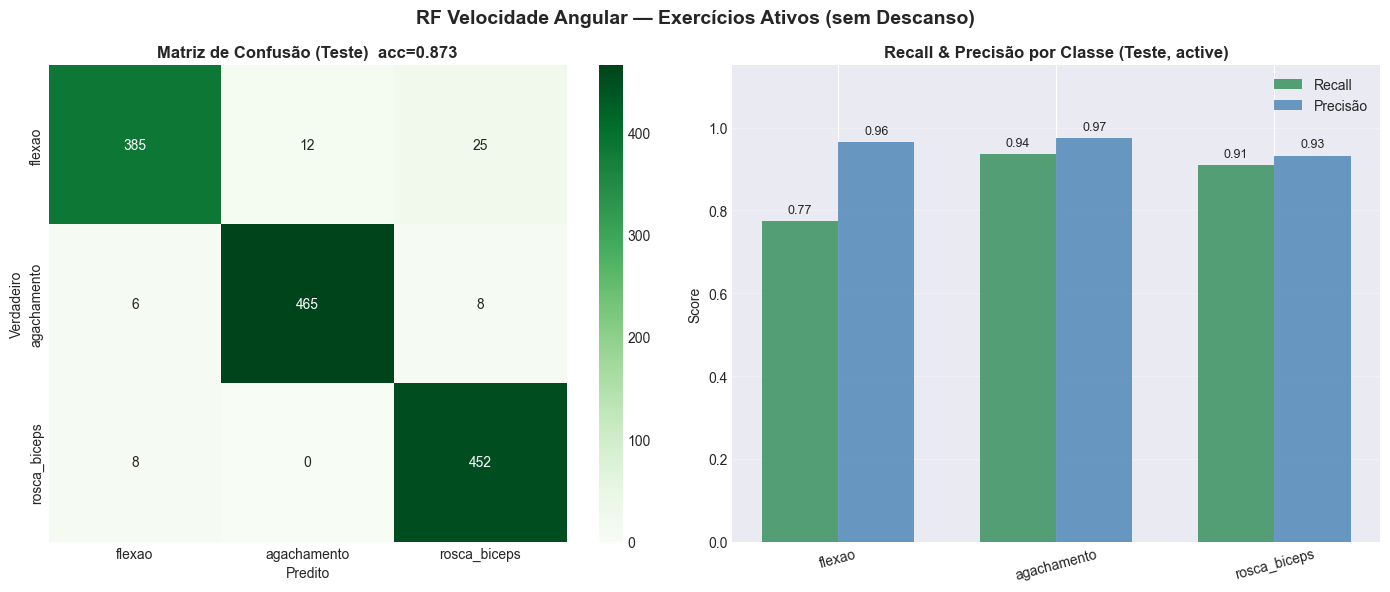

In [90]:
# ── Filtrar apenas exercícios ativos (excluindo descanso) ────────────────────
active_labels = {k: v for k, v in label_map.items() if k != 'descanso'}
active_label_values = list(active_labels.values())

active_mask_test  = y_test.isin(active_label_values)
active_mask_train = y_train.isin(active_label_values)

y_test_active  = y_test[active_mask_test].reset_index(drop=True)
y_train_active = y_train[active_mask_train].reset_index(drop=True)
y_test_pred_act  = y_test_pred[active_mask_test]
y_train_pred_act = y_train_pred[active_mask_train]

active_names = [reverse_label_map[i] for i in sorted(active_label_values)]

acc_train_active = accuracy_score(y_train_active, y_train_pred_act)
acc_test_active  = accuracy_score(y_test_active,  y_test_pred_act)

print("=" * 65)
print("  ACURÁCIA — APENAS EXERCÍCIOS ATIVOS (flexão, agach., rosca)")
print("=" * 65)
print(f"\n  {'Conjunto':<12} {'Acurácia (active)':>18}")
print(f"  {'-'*32}")
print(f"  {'Treino':<12} {acc_train_active:>18.4f}")
print(f"  {'Teste':<12} {acc_test_active:>18.4f}")

print(f"\n{'='*65}")
print("  CLASSIFICATION REPORT — TREINO (active)")
print(f"{'='*65}")
print(classification_report(y_train_active, y_train_pred_act,
                             labels=sorted(active_label_values),
                             target_names=active_names, zero_division=0))

print(f"{'='*65}")
print("  CLASSIFICATION REPORT — TESTE (active)")
print(f"{'='*65}")
print(classification_report(y_test_active, y_test_pred_act,
                             labels=sorted(active_label_values),
                             target_names=active_names, zero_division=0))

# ── Gráfico ──────────────────────────────────────────────────────────────────
cm_active = confusion_matrix(y_test_active, y_test_pred_act,
                             labels=sorted(active_label_values))
report_active = classification_report(y_test_active, y_test_pred_act,
                                      labels=sorted(active_label_values),
                                      target_names=active_names,
                                      output_dict=True, zero_division=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('RF Velocidade Angular — Exercícios Ativos (sem Descanso)',
             fontsize=14, fontweight='bold')

sns.heatmap(cm_active, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=active_names, yticklabels=active_names)
axes[0].set_title(f'Matriz de Confusão (Teste)  acc={acc_test_active:.3f}',
                  fontweight='bold')
axes[0].set_ylabel('Verdadeiro'); axes[0].set_xlabel('Predito')

rec  = [report_active[c]['recall']    for c in active_names]
prec = [report_active[c]['precision'] for c in active_names]
x = np.arange(len(active_names))
w = 0.35
axes[1].bar(x - w/2, rec,  w, label='Recall',   color='seagreen',  alpha=0.8)
axes[1].bar(x + w/2, prec, w, label='Precisão', color='steelblue', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(active_names, rotation=15)
axes[1].set_ylim([0, 1.15]); axes[1].set_ylabel('Score')
axes[1].set_title('Recall & Precisão por Classe (Teste, active)', fontweight='bold')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
for i, (r, p) in enumerate(zip(rec, prec)):
    axes[1].text(i - w/2, r + 0.02, f'{r:.2f}', ha='center', fontsize=9)
    axes[1].text(i + w/2, p + 0.02, f'{p:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Save Model and Artifacts

In [91]:
# print("💾 Salvando artefatos...\n")

# # Salvar pipeline completo (scaler + RF em um único objeto)
# pipe_path = ML_MODELS_DIR / "random_forest_velocity_pipeline.pkl"
# with open(pipe_path, 'wb') as f:
#     pickle.dump(pipe, f)
# pipe_size = pipe_path.stat().st_size / 1024
# print(f"  ✓ Pipeline (scaler + RF): {pipe_path} ({pipe_size:.1f} KB)")

# # Salvar modelo e scaler separadamente
# model_path = ML_MODELS_DIR / "random_forest_velocity_4exercises.pkl"
# with open(model_path, 'wb') as f:
#     pickle.dump(pipe.named_steps['rf'], f)
# model_size = model_path.stat().st_size / 1024
# print(f"  ✓ Modelo RF:              {model_path} ({model_size:.1f} KB)")

# scaler_path = ML_MODELS_DIR / "random_forest_velocity_4exercises_scaler.pkl"
# with open(scaler_path, 'wb') as f:
#     pickle.dump(pipe.named_steps['scaler'], f)
# scaler_size = scaler_path.stat().st_size / 1024
# print(f"  ✓ Scaler:                 {scaler_path} ({scaler_size:.1f} KB)")

# # Salvar label map
# label_map_path = ML_MODELS_DIR / "random_forest_velocity_4exercises_label_map.pkl"
# with open(label_map_path, 'wb') as f:
#     pickle.dump(label_map, f)
# print(f"  ✓ Label Map:              {label_map_path}")

# n_features = pipe.named_steps['scaler'].n_features_in_
# print(f"\n  📐 Scaler treinado com {n_features} features  ({n_features // len(angle_columns)} deltas × {len(angle_columns)} ângulos)")
# print(f"  ℹ️  Inferência: calcule os deltas da janela → scaler.transform → rf.predict")